# Tox21 Drug Toxicity Prediction — Final Research Notebook

এই notebook তৈরি করা হয়েছে দুইটি notebook পুরো পড়ে merge/refine করে:

1. `6. Tox21_Drug_Toxicity_New.ipynb` থেকে **preprocessing + visualization + ensemble/reporting structure** রাখা হয়েছে।
2. `new_tox.ipynb` থেকে **requested model list** রাখা হয়েছে।

Final evaluation metric শুধু দুইটি: **AUC-ROC** এবং **Accuracy**।  
Dataset split: **75% train / 25% test**।  
Cross-validation: **3-fold CV**।

## 0. Environment setup

RDKit, XGBoost, LightGBM, TensorFlow, PyTorch, Transformers দরকার হতে পারে। Colab/Kaggle/local environment-এ package missing হলে নিচের install line uncomment করে run করো।

In [ ]:
# প্রয়োজন হলে uncomment করো:
# !pip -q install rdkit-pypi xgboost lightgbm tensorflow transformers torch torchvision pillow joblib

## 1. Import libraries

Data handling, visualization, chemical preprocessing, ML, DL, CV, evaluation এবং saving tools import করা হলো। Optional package না থাকলে notebook skip করবে, crash করবে না।

In [1]:
import os
import gc
import math
import json
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.base import clone

from scipy.sparse import hstack, csr_matrix
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [2]:
# Optional chemistry package
try:
    from rdkit import Chem, DataStructs
    from rdkit.Chem import AllChem, MACCSkeys, Descriptors
    from rdkit.Chem.MolStandardize import rdMolStandardize
    from rdkit.Chem import Draw
    RDKIT_AVAILABLE = True
    print("RDKit available")
except Exception as e:
    RDKIT_AVAILABLE = False
    print("RDKit unavailable:", e)

RDKit available


In [3]:
# Optional boosting packages
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("XGBoost available")
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print("LightGBM available")
except Exception as e:
    LGBM_AVAILABLE = False
    print("LightGBM unavailable:", e)

XGBoost available
LightGBM available


In [6]:
# Optional deep learning packages
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
    print("TensorFlow available")
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow unavailable:", e)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
    print("PyTorch available")
except Exception as e:
    TORCH_AVAILABLE = False
    print("PyTorch unavailable:", e)

try:
    from transformers import AutoTokenizer, AutoModel
    TRANSFORMERS_AVAILABLE = True
    print("Transformers available")
except Exception as e:
    TRANSFORMERS_AVAILABLE = False
    print("Transformers unavailable:", e)

TensorFlow available
PyTorch available
Transformers available


## 2. Global configuration

Reproducibility, split ratio, fingerprint size, CV folds, training epochs এবং output folder define করা হলো।

In [7]:
DATA_PATH_CANDIDATES = [
    "/mnt/data/tox21.csv",
    "tox21.csv",
    "/content/tox21.csv",
]
DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError("tox21.csv পাওয়া যায়নি। Notebook folder বা /content এ tox21.csv রাখো।")

TEST_SIZE = 0.25
CV_FOLDS = 3
N_BITS = 2048
RADIUS = 2
N_JOBS = -1
THRESHOLD = 0.50

# Heavy model settings: ভালো output এর জন্য epochs বাড়ানো যাবে।
DNN_EPOCHS = 25
DNN_CV_EPOCHS = 8
DENSENET_BATCH_SIZE = 32
IMAGE_SIZE = 224
CHEMBERTA_MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1"
GNN_MAX_ATOMS = 80

RESULT_DIR = Path("tox21_final_outputs")
RESULT_DIR.mkdir(exist_ok=True)

all_predictions = {}
all_endpoint_results = {}
cv_records = []
trained_models = {}

print("Using dataset:", DATA_PATH)

Using dataset: tox21.csv


## 3. Load Tox21 dataset

Tox21 dataset multi-label binary classification problem। `smiles` molecule structure, আর 12 toxicity endpoints target label। Missing labels `NaN` হিসেবেই রাখা হবে।

In [13]:
df = pd.read_csv(DATA_PATH)

df_raw = pd.read_csv(DATA_PATH)
print("Using dataset:", DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()

Using dataset: tox21.csv
Raw shape: (7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [14]:
TARGET_COLS = [c for c in df_raw.columns if c not in ["mol_id", "smiles"]]
print("Number of Tox21 endpoints:", len(TARGET_COLS))
print(TARGET_COLS)

for col in TARGET_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

Number of Tox21 endpoints: 12
['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


## 4. Endpoint-wise missing value and imbalance summary

প্রতিটি endpoint-এ কত labeled, toxic, non-toxic, missing এবং imbalance আছে সেটা দেখা হলো।

In [15]:
def make_endpoint_summary(df, target_cols):
    rows = []
    total = len(df)
    for col in target_cols:
        y = df[col]
        labeled = int(y.notna().sum())
        pos = int((y == 1).sum())
        neg = int((y == 0).sum())
        missing = int(y.isna().sum())
        pos_rate = (pos / labeled * 100) if labeled else np.nan
        missing_pct = missing / total * 100
        ratio = (neg / max(pos, 1)) if pos else np.inf
        rows.append({
            "Endpoint": col,
            "Labeled": labeled,
            "Toxic (1)": pos,
            "Non-Toxic (0)": neg,
            "Missing": missing,
            "Missing %": round(missing_pct, 1),
            "Pos Rate %": round(pos_rate, 1),
            "Imbalance": f"{ratio:.1f} : 1" if np.isfinite(ratio) else "inf"
        })
    return pd.DataFrame(rows)

endpoint_summary = make_endpoint_summary(df_raw, TOX21_ENDPOINTS)
display(endpoint_summary)

,Endpoint,Labeled,Toxic (1),Non-Toxic (0),Missing,Missing %,Pos Rate %,Imbalance
0,NR-AR,7265,309,6956,566,7.2,4.3,22.5 : 1
1,NR-AR-LBD,6758,237,6521,1073,13.7,3.5,27.5 : 1
2,NR-AhR,6549,768,5781,1282,16.4,11.7,7.5 : 1
3,NR-Aromatase,5821,300,5521,2010,25.7,5.2,18.4 : 1
4,NR-ER,6193,793,5400,1638,20.9,12.8,6.8 : 1
5,NR-ER-LBD,6955,350,6605,876,11.2,5.0,18.9 : 1
6,NR-PPAR-gamma,6450,186,6264,1381,17.6,2.9,33.7 : 1
7,SR-ARE,5832,942,4890,1999,25.5,16.2,5.2 : 1
8,SR-ATAD5,7072,264,6808,759,9.7,3.7,25.8 : 1
9,SR-HSE,6467,372,6095,1364,17.4,5.8,16.4 : 1


## 5. Visualization — dataset challenges

First notebook-এর মতো missing value এবং positive toxic rate visual করা হলো। Red = severe, orange = moderate, green = acceptable।

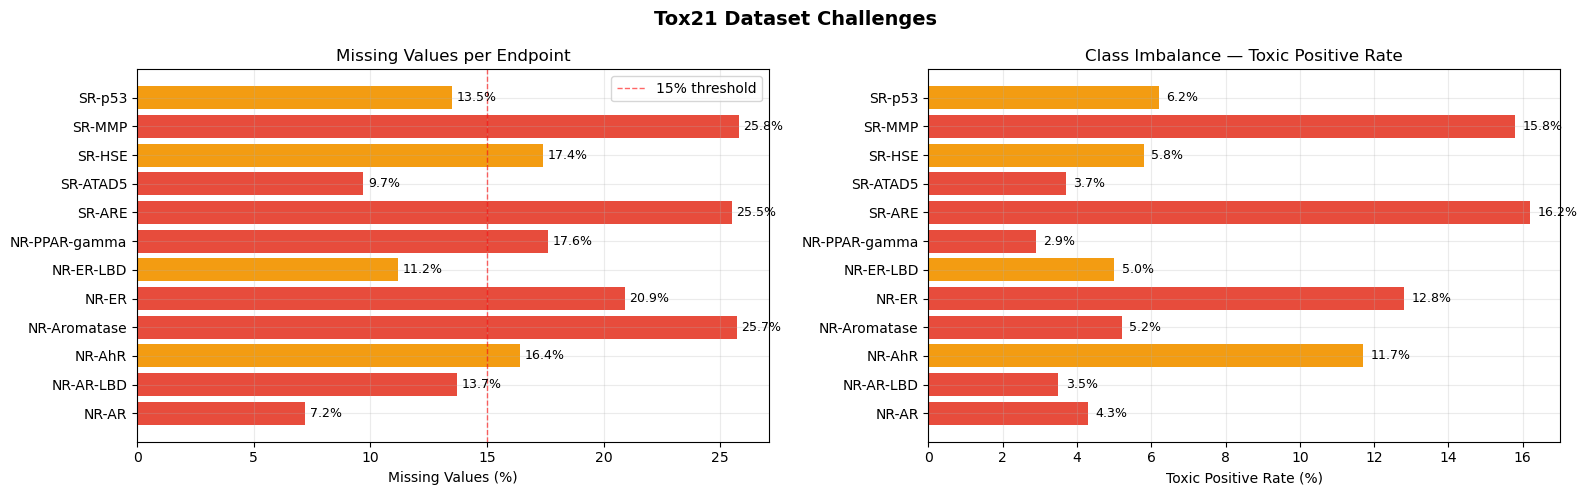

In [16]:
def severity_color(missing_pct, pos_rate):
    if missing_pct > 20 or pos_rate < 5:
        return "#e74c3c"  # severe
    if missing_pct > 15 or pos_rate < 8:
        return "#f39c12"  # moderate
    return "#2ecc71"      # acceptable

missing_pct = endpoint_summary["Missing %"].values
pos_rate = endpoint_summary["Pos Rate %"].values
colors = [severity_color(m, p) for m, p in zip(missing_pct, pos_rate)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(endpoint_summary["Endpoint"], missing_pct, color=colors)
axes[0].axvline(15, linestyle="--", linewidth=1, color="red", alpha=0.6, label="15% threshold")
axes[0].set_title("Missing Values per Endpoint")
axes[0].set_xlabel("Missing Values (%)")
axes[0].legend()
axes[0].grid(alpha=0.25)
for i, v in enumerate(missing_pct):
    axes[0].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)

axes[1].barh(endpoint_summary["Endpoint"], pos_rate, color=colors)
axes[1].set_title("Class Imbalance — Toxic Positive Rate")
axes[1].set_xlabel("Toxic Positive Rate (%)")
axes[1].grid(alpha=0.25)
for i, v in enumerate(pos_rate):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)

fig.suptitle("Tox21 Dataset Challenges", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

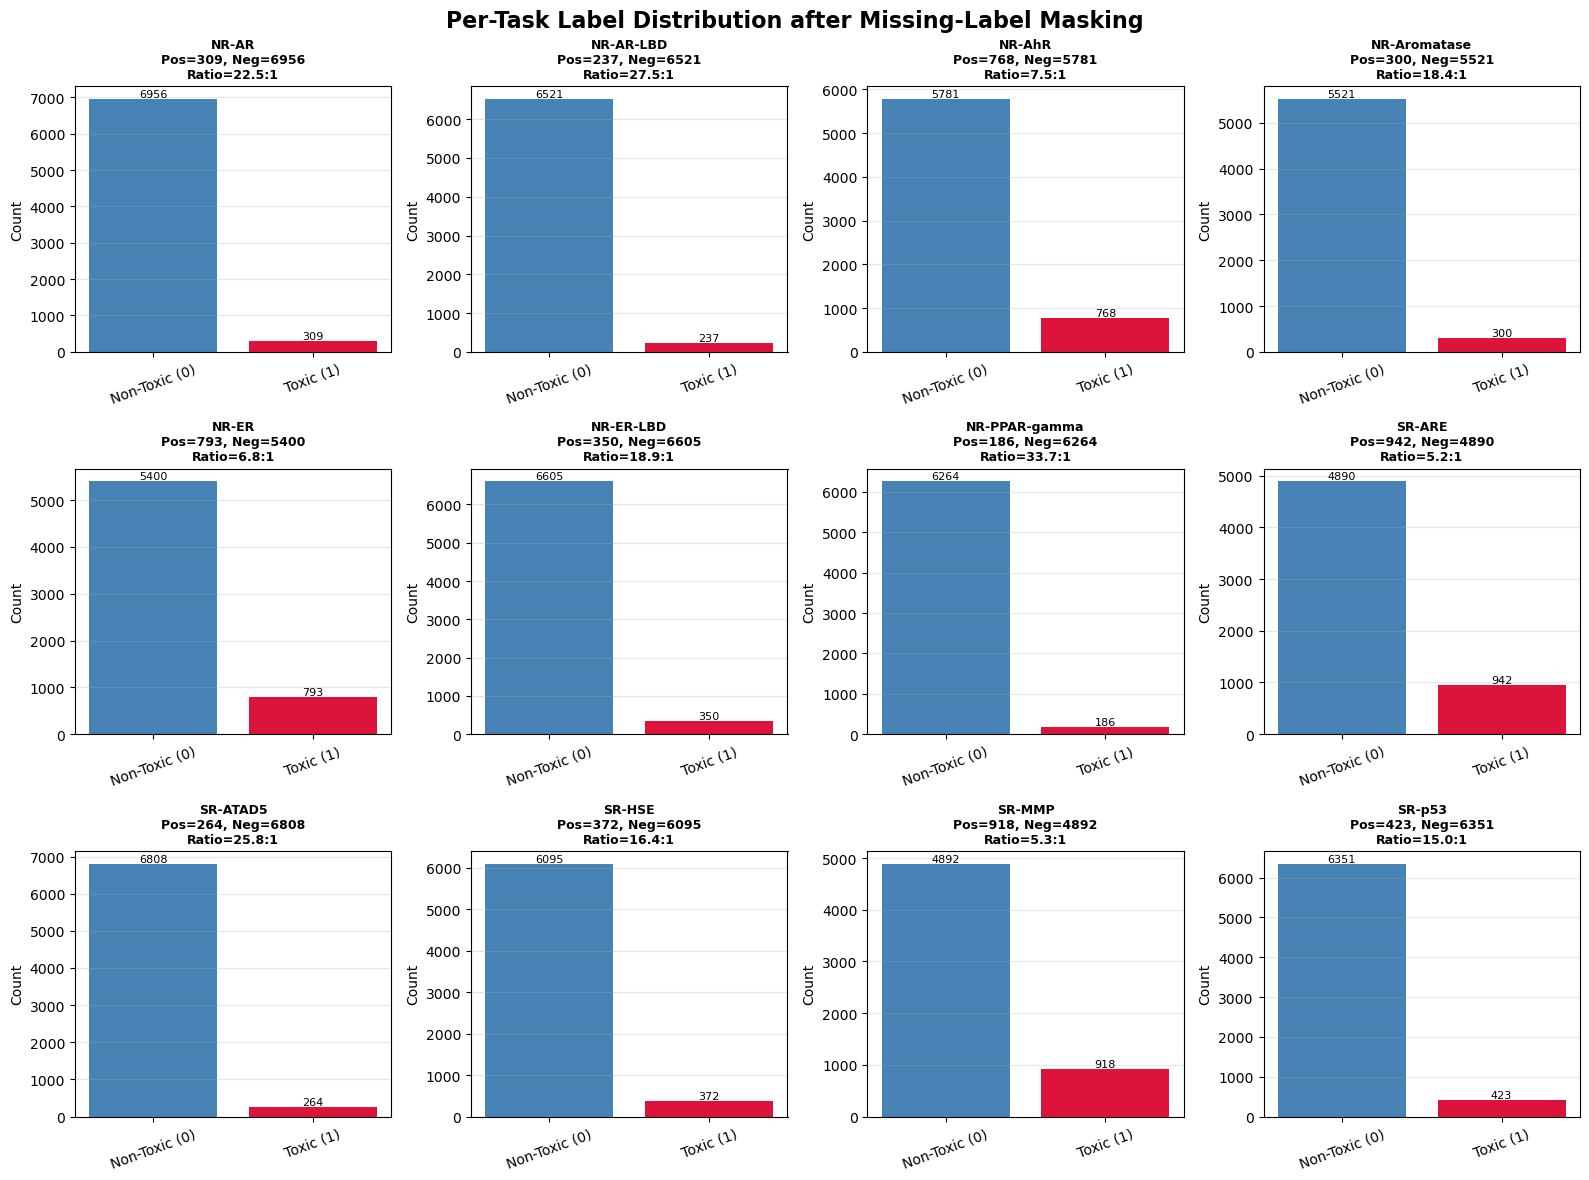

In [17]:
# ==========================================================
# Per-Task Label Distribution after Missing-Label Masking
# ==========================================================

import math
import matplotlib.pyplot as plt

n_cols = 4
n_rows = math.ceil(len(TARGET_COLS) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.ravel()

for i, task in enumerate(TARGET_COLS):

    # Remove missing labels
    y_valid = df_raw[task].dropna().astype(int)

    # Count positive & negative samples
    n_neg = int((y_valid == 0).sum())
    n_pos = int((y_valid == 1).sum())

    # Plot
    axes[i].bar(
        ["Non-Toxic (0)", "Toxic (1)"],
        [n_neg, n_pos],
        color=["steelblue", "crimson"]
    )

    # Title
    axes[i].set_title(
        f"{task}\nPos={n_pos}, Neg={n_neg}\nRatio={n_neg/max(n_pos,1):.1f}:1",
        fontsize=9,
        fontweight="bold"
    )

    axes[i].set_ylabel("Count")
    axes[i].grid(axis="y", alpha=0.30)

    # Value labels
    axes[i].text(
        0, n_neg,
        str(n_neg),
        ha="center",
        va="bottom",
        fontsize=8
    )

    axes[i].text(
        1, n_pos,
        str(n_pos),
        ha="center",
        va="bottom",
        fontsize=8
    )

    axes[i].tick_params(axis="x", labelrotation=20)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Per-Task Label Distribution after Missing-Label Masking",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 6. Chemical preprocessing

Best-output এর জন্য first notebook-এর preprocessing technique রাখা হয়েছে:

- invalid SMILES remove
- largest fragment selection
- normalization
- uncharge
- sanitize
- canonical SMILES generation
- duplicate canonical SMILES remove

Missing toxicity labels fill করা হবে না।

In [21]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
if not RDKIT_AVAILABLE:
    raise ImportError("RDKit ছাড়া এই notebook চালানো যাবে না। RDKit install করো।")

largest_fragment = rdMolStandardize.LargestFragmentChooser()
normalizer = rdMolStandardize.Normalizer()
uncharger = rdMolStandardize.Uncharger()

def standardize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None, None, "invalid_parse"
        mol = largest_fragment.choose(mol)
        mol = normalizer.normalize(mol)
        mol = uncharger.uncharge(mol)
        Chem.SanitizeMol(mol)
        can = Chem.MolToSmiles(mol, canonical=True)
        mol2 = Chem.MolFromSmiles(can)
        return can, mol2, "ok"
    except Exception as e:
        return None, None, str(e)

In [22]:
df = df_raw.copy()
records = []
for smi in df["smiles"]:
    can, mol, status = standardize_smiles(smi)
    records.append((can, mol, status))

df["canonical_smiles"] = [r[0] for r in records]
df["mol"] = [r[1] for r in records]
df["standardize_status"] = [r[2] for r in records]

print("Before cleaning:", df.shape)
print("Invalid SMILES:", int(df["mol"].isna().sum()))

df = df[df["mol"].notna()].copy()
dup_count = int(df.duplicated("canonical_smiles").sum())
print("Duplicate canonical SMILES:", dup_count)

df = df.drop_duplicates("canonical_smiles").reset_index(drop=True)
print("After cleaning:", df.shape)

Before cleaning: (7831, 17)
Invalid SMILES: 9
Duplicate canonical SMILES: 211
After cleaning: (7611, 17)


## 7. Show one cleaned molecule

Sanity check হিসেবে একটি molecule draw করা হলো।

Canonical SMILES: CCOc1ccc2nc(S(N)(=O)=O)sc2c1


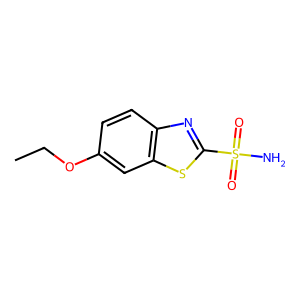

In [23]:
from IPython.display import SVG, display

sample_smiles = df["canonical_smiles"].iloc[0]
print("Canonical SMILES:", sample_smiles)

mol = Chem.MolFromSmiles(sample_smiles)
drawer = Draw.rdMolDraw2D.MolDraw2DSVG(300, 300)
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
display(SVG(drawer.GetDrawingText()))

## 8. Feature engineering — Morgan ECFP4 + MACCS + RDKit descriptors

Classical ML এবং hybrid models-এর জন্য chemical representation তৈরি করা হলো।

In [26]:
def morgan_fp(mol, n_bits=N_BITS, radius=RADIUS):
    arr = np.zeros((n_bits,), dtype=np.int8)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def maccs_fp(mol):
    arr = np.zeros((167,), dtype=np.int8)
    fp = MACCSkeys.GenMACCSKeys(mol)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

descriptor_names = [name for name, _ in Descriptors._descList]
descriptor_funcs = [func for _, func in Descriptors._descList]

def rdkit_descriptors(mol):
    vals = []
    for func in descriptor_funcs:
        try:
            vals.append(float(func(mol)))
        except Exception:
            vals.append(np.nan)
    return vals

In [27]:
mols = df["mol"].tolist()
smiles_clean = df["canonical_smiles"].tolist()
Y = df[TOX21_ENDPOINTS].values.astype(float)

X_morgan = np.vstack([morgan_fp(m) for m in mols]).astype(np.float32)
X_maccs = np.vstack([maccs_fp(m) for m in mols]).astype(np.float32)
X_fp = np.hstack([X_morgan, X_maccs]).astype(np.float32)

X_desc_raw = pd.DataFrame([rdkit_descriptors(m) for m in mols], columns=descriptor_names)
X_desc_raw = X_desc_raw.replace([np.inf, -np.inf], np.nan)

print("Morgan:", X_morgan.shape)
print("MACCS:", X_maccs.shape)
print("Raw descriptors:", X_desc_raw.shape)
print("Targets:", Y.shape)

Morgan: (7611, 2048)
MACCS: (7611, 167)
Raw descriptors: (7611, 217)
Targets: (7611, 12)


## 9. Dataset split — 75% train / 25% test

এখানে dataset ২ ভাগ করা হচ্ছে: **75% training** এবং **25% final testing**। Test set untouched থাকবে।

In [28]:
# Row-level stratification: molecule-এ অন্তত একটি toxic label আছে কিনা
row_stratify = (np.nan_to_num(Y, nan=0).sum(axis=1) > 0).astype(int)
stratify_arg = row_stratify if len(np.unique(row_stratify)) == 2 else None

train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_arg
)

print(f"✅ ডেটাসেট ২ ভাগ করা হলো: Train = 75% ({len(train_idx)} samples), Test = 25% ({len(test_idx)} samples)")

Y_train = Y[train_idx]
Y_test = Y[test_idx]
train_smiles = [smiles_clean[i] for i in train_idx]
test_smiles = [smiles_clean[i] for i in test_idx]
train_mols = [mols[i] for i in train_idx]
test_mols = [mols[i] for i in test_idx]

✅ ডেটাসেট ২ ভাগ করা হলো: Train = 75% (5708 samples), Test = 25% (1903 samples)


## 10. Train-only descriptor imputation and scaling

Data leakage avoid করার জন্য imputer/scaler শুধুমাত্র train split-এ fit হবে। Test split-এ transform only।

In [29]:
def build_chemical_features(fit_indices, transform_indices):
    """Fit imputer/scaler on fit_indices and transform transform_indices."""
    imp = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    desc_fit = imp.fit_transform(X_desc_raw.iloc[fit_indices])
    desc_fit = scaler.fit_transform(desc_fit)

    desc_transform = imp.transform(X_desc_raw.iloc[transform_indices])
    desc_transform = scaler.transform(desc_transform)

    X_fit = np.hstack([X_fp[fit_indices], desc_fit]).astype(np.float32)
    X_transform = np.hstack([X_fp[transform_indices], desc_transform]).astype(np.float32)
    return X_fit, X_transform, imp, scaler

X_train_chem, X_test_chem, desc_imputer, desc_scaler = build_chemical_features(train_idx, test_idx)

print("Final chemical train feature shape:", X_train_chem.shape)
print("Final chemical test feature shape:", X_test_chem.shape)

Final chemical train feature shape: (5708, 2432)
Final chemical test feature shape: (1903, 2432)


## 11. Evaluation helpers — AUC-ROC and Accuracy only

Final requirement অনুযায়ী metric শুধু **AUC-ROC** এবং **Accuracy**। Missing labels ignore করা হবে।

In [30]:
def safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_prob = y_prob[mask]
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)

def safe_acc(y_true, y_prob, threshold=THRESHOLD):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_prob = y_prob[mask]
    if len(y_true) == 0:
        return np.nan
    y_pred = (y_prob >= threshold).astype(int)
    return accuracy_score(y_true, y_pred)

def evaluate_prediction_matrix(model_name, Y_true, P, threshold=THRESHOLD):
    rows = []
    for j, ep in enumerate(TOX21_ENDPOINTS):
        y = Y_true[:, j]
        p = P[:, j]
        mask = ~np.isnan(y)
        rows.append({
            "Model": model_name,
            "Endpoint": ep,
            "n_labeled": int(mask.sum()),
            "n_pos": int(np.nansum(y == 1)),
            "n_neg": int(np.nansum(y == 0)),
            "AUC": safe_auc(y, p),
            "Accuracy": safe_acc(y, p, threshold=threshold)
        })
    out = pd.DataFrame(rows)
    return out

def register_predictions(model_name, Y_true, P):
    all_predictions[model_name] = P
    res = evaluate_prediction_matrix(model_name, Y_true, P)
    all_endpoint_results[model_name] = res
    print(f"{model_name} | Mean AUC={res['AUC'].mean():.4f} | Mean Acc={res['Accuracy'].mean():.4f}")
    display(res[["Endpoint", "AUC", "Accuracy", "n_pos", "n_neg"]])
    return res

## 12. Single-task model trainer

প্রতিটি endpoint-এর missing labels বাদ দিয়ে আলাদা binary classifier train করা হবে।

In [31]:
def predict_positive_probability(model, X):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if isinstance(proba, list):
            proba = proba[0]
        if proba.shape[1] == 1:
            return np.zeros(X.shape[0], dtype=float)
        return proba[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return 1 / (1 + np.exp(-scores))
    return model.predict(X).astype(float)

def train_per_endpoint_model(model_name, model_factory, Xtr, Ytr, Xte, Yte):
    P = np.full((Xte.shape[0], len(TOX21_ENDPOINTS)), np.nan, dtype=float)
    models = {}

    for j, ep in enumerate(TOX21_ENDPOINTS):
        ytr = Ytr[:, j]
        mask_tr = ~np.isnan(ytr)

        if mask_tr.sum() < 5 or len(np.unique(ytr[mask_tr])) < 2:
            P[:, j] = np.nanmean(ytr)
            continue

        model = model_factory(ytr[mask_tr])
        model.fit(Xtr[mask_tr], ytr[mask_tr].astype(int))
        P[:, j] = predict_positive_probability(model, Xte)
        models[ep] = model

    trained_models[model_name] = models
    return register_predictions(model_name, Yte, P)

## 13. 3-fold CV helper for single-task ML models

CV শুধু train split-এর ভিতরে হবে। Test set final evaluation-এর আগে untouched থাকবে।

In [32]:
def run_3fold_cv_for_model(model_name, model_factory, base_indices=train_idx, feature_mode="chemical", X_fixed=None):
    row_y = (np.nan_to_num(Y[base_indices], nan=0).sum(axis=1) > 0).astype(int)
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    fold_scores = []
    for fold, (tr_rel, va_rel) in enumerate(skf.split(base_indices, row_y), start=1):
        tr_abs = base_indices[tr_rel]
        va_abs = base_indices[va_rel]

        if feature_mode == "chemical":
            Xtr, Xva, _, _ = build_chemical_features(tr_abs, va_abs)
        elif feature_mode == "fixed":
            Xtr, Xva = X_fixed[tr_rel], X_fixed[va_rel]
        else:
            raise ValueError("feature_mode must be 'chemical' or 'fixed'")

        Ytr, Yva = Y[tr_abs], Y[va_abs]
        Pva = np.full((len(va_abs), len(TOX21_ENDPOINTS)), np.nan, dtype=float)

        for j, ep in enumerate(TOX21_ENDPOINTS):
            ytr = Ytr[:, j]
            mask_tr = ~np.isnan(ytr)
            if mask_tr.sum() < 5 or len(np.unique(ytr[mask_tr])) < 2:
                continue
            model = model_factory(ytr[mask_tr])
            model.fit(Xtr[mask_tr], ytr[mask_tr].astype(int))
            Pva[:, j] = predict_positive_probability(model, Xva)

        fold_res = evaluate_prediction_matrix(model_name, Yva, Pva)
        fold_scores.append({
            "Model": model_name,
            "Fold": fold,
            "CV AUC": fold_res["AUC"].mean(),
            "CV Accuracy": fold_res["Accuracy"].mean()
        })
        print(f"{model_name} fold {fold}: AUC={fold_scores[-1]['CV AUC']:.4f}, Acc={fold_scores[-1]['CV Accuracy']:.4f}")

    cv_df = pd.DataFrame(fold_scores)
    cv_records.extend(fold_scores)
    return cv_df

## 14. Model 1 — Random Forest

Tree ensemble baseline; imbalanced endpoint-এর জন্য `class_weight='balanced_subsample'` use করা হয়েছে।

In [33]:
def rf_factory(y):
    return RandomForestClassifier(
        n_estimators=450,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    )

cv_rf = run_3fold_cv_for_model("Random Forest", rf_factory)
res_rf = train_per_endpoint_model("Random Forest", rf_factory, X_train_chem, Y_train, X_test_chem, Y_test)

Random Forest fold 1: AUC=0.8466, Acc=0.9391
Random Forest fold 2: AUC=0.8600, Acc=0.9381
Random Forest fold 3: AUC=0.8397, Acc=0.9375
Random Forest | Mean AUC=0.8504 | Mean Acc=0.9402


,Endpoint,AUC,Accuracy,n_pos,n_neg
0,NR-AR,0.794445,0.974929,71,1684
1,NR-AR-LBD,0.867302,0.982198,50,1579
2,NR-AhR,0.912762,0.917303,181,1391
3,NR-Aromatase,0.856891,0.963388,57,1336
4,NR-ER,0.734076,0.892905,182,1312
5,NR-ER-LBD,0.840463,0.964392,82,1603
6,NR-PPAR-gamma,0.883620,0.975301,38,1541
7,SR-ARE,0.833792,0.853989,238,1166
8,SR-ATAD5,0.894367,0.964851,62,1645
9,SR-HSE,0.787319,0.945386,88,1505


## 15. Model 2 — Extra Trees

Random Forest-এর stronger randomized alternative।

In [ ]:
def et_factory(y):
    return ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    )

cv_et = run_3fold_cv_for_model("Extra Trees", et_factory)
res_et = train_per_endpoint_model("Extra Trees", et_factory, X_train_chem, Y_train, X_test_chem, Y_test)

## 16. Model 3 — XGBoost

Endpoint-wise positive/negative ratio দিয়ে imbalance handling করা হয়েছে।

In [ ]:
if XGB_AVAILABLE:
    def xgb_factory(y):
        pos = max(np.sum(y == 1), 1)
        neg = max(np.sum(y == 0), 1)
        return XGBClassifier(
            n_estimators=350,
            max_depth=5,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=neg / pos,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            tree_method="hist"
        )

    cv_xgb = run_3fold_cv_for_model("XGBoost", xgb_factory)
    res_xgb = train_per_endpoint_model("XGBoost", xgb_factory, X_train_chem, Y_train, X_test_chem, Y_test)
else:
    print("XGBoost skipped because package is unavailable.")

## 17. Model 4 — LightGBM

Fast gradient boosting model; class imbalance handle করতে `scale_pos_weight` ব্যবহার করা হয়েছে।

In [ ]:
if LGBM_AVAILABLE:
    def lgbm_factory(y):
        pos = max(np.sum(y == 1), 1)
        neg = max(np.sum(y == 0), 1)
        return LGBMClassifier(
            n_estimators=450,
            learning_rate=0.03,
            num_leaves=48,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=neg / pos,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbose=-1
        )

    cv_lgbm = run_3fold_cv_for_model("LightGBM", lgbm_factory)
    res_lgbm = train_per_endpoint_model("LightGBM", lgbm_factory, X_train_chem, Y_train, X_test_chem, Y_test)
else:
    print("LightGBM skipped because package is unavailable.")

## 18. Model 5 — SVM RBF

User requirement অনুযায়ী Linear SVM বাদ দিয়ে **SVM RBF** রাখা হয়েছে। Runtime বেশি হতে পারে, কিন্তু অনেক endpoint-এ better nonlinear boundary capture করতে পারে।

In [ ]:
def svm_rbf_factory(y):
    return SVC(
        kernel="rbf",
        C=3.0,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        cache_size=2500,
        random_state=RANDOM_STATE
    )

cv_svm = run_3fold_cv_for_model("SVM RBF", svm_rbf_factory)
res_svm = train_per_endpoint_model("SVM RBF", svm_rbf_factory, X_train_chem, Y_train, X_test_chem, Y_test)

## 19. Deep learning utilities — missing-label mask + class imbalance

DeepTox/CapsNet/GNN/DenseNet models 12 labels একসাথে learn করবে। Missing label loss-এ contribute করবে না।

In [ ]:
def make_multitask_arrays(Ymat):
    y = np.nan_to_num(Ymat, nan=0.0).astype(np.float32)
    mask = (~np.isnan(Ymat)).astype(np.float32)

    # class imbalance weight per endpoint: negative/positive for positive samples
    weights = mask.copy()
    for j in range(Ymat.shape[1]):
        yy = Ymat[:, j]
        pos = np.nansum(yy == 1)
        neg = np.nansum(yy == 0)
        pos_w = float(neg / max(pos, 1))
        weights[:, j] = np.where(y[:, j] == 1, pos_w, 1.0) * mask[:, j]
    return y, weights

if TF_AVAILABLE:
    keras.utils.set_random_seed(RANDOM_STATE)

## 20. Model 6 — DeepTox-style Multitask DNN

DeepTox paper-এর idea অনুযায়ী multi-task DNN 12 endpoints একসাথে learn করবে।

In [ ]:
if TF_AVAILABLE:
    def build_deeptox_dnn(input_dim, n_tasks=len(TOX21_ENDPOINTS)):
        inp = keras.Input(shape=(input_dim,), name="chemical_features")
        x = layers.BatchNormalization()(inp)
        x = layers.Dense(1024, activation="relu")(x)
        x = layers.Dropout(0.35)(x)
        x = layers.Dense(512, activation="relu")(x)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(256, activation="relu", name="deeptox_embedding")(x)
        out = layers.Dense(n_tasks, activation="sigmoid", name="toxicity_outputs")(x)
        model = keras.Model(inp, out, name="DeepTox_style_DNN")
        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
        return model

    ytr_filled, sw_train = make_multitask_arrays(Y_train)
    deeptox_model = build_deeptox_dnn(X_train_chem.shape[1])
    deeptox_model.fit(
        X_train_chem, ytr_filled,
        sample_weight=sw_train,
        epochs=DNN_EPOCHS,
        batch_size=128,
        validation_split=0.10,
        verbose=1,
        callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
    )
    P_deeptox = deeptox_model.predict(X_test_chem, batch_size=256, verbose=0)
    trained_models["DeepTox-style DNN"] = deeptox_model
    res_deeptox = register_predictions("DeepTox-style DNN", Y_test, P_deeptox)
else:
    print("DeepTox-style DNN skipped because TensorFlow is unavailable.")

## 21. 3-fold CV — DeepTox-style DNN

DNN-এর জন্যও 3-fold CV রাখা হলো। Runtime কম রাখতে CV epochs আলাদা define করা হয়েছে।

In [ ]:
if TF_AVAILABLE:
    row_y = (np.nan_to_num(Y[train_idx], nan=0).sum(axis=1) > 0).astype(int)
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    for fold, (tr_rel, va_rel) in enumerate(skf.split(train_idx, row_y), start=1):
        tr_abs, va_abs = train_idx[tr_rel], train_idx[va_rel]
        Xtr, Xva, _, _ = build_chemical_features(tr_abs, va_abs)
        Ytr, Yva = Y[tr_abs], Y[va_abs]
        ytr, sw = make_multitask_arrays(Ytr)
        model = build_deeptox_dnn(Xtr.shape[1])
        model.fit(Xtr, ytr, sample_weight=sw, epochs=DNN_CV_EPOCHS, batch_size=128, verbose=0)
        Pva = model.predict(Xva, batch_size=256, verbose=0)
        fold_res = evaluate_prediction_matrix("DeepTox-style DNN", Yva, Pva)
        cv_records.append({"Model": "DeepTox-style DNN", "Fold": fold, "CV AUC": fold_res["AUC"].mean(), "CV Accuracy": fold_res["Accuracy"].mean()})
        print(f"DeepTox-style DNN fold {fold}: AUC={fold_res['AUC'].mean():.4f}, Acc={fold_res['Accuracy'].mean():.4f}")
        keras.backend.clear_session(); gc.collect()

## 22. Model 7 — Multitask CapsNet-style model

CapsNet paper থেকে idea: imbalanced sparse minority class-এর finer pattern learn করতে capsule-style representation useful হতে পারে।

In [ ]:
if TF_AVAILABLE:
    def squash(x, axis=-1, eps=1e-7):
        s2 = tf.reduce_sum(tf.square(x), axis=axis, keepdims=True)
        scale = s2 / (1.0 + s2) / tf.sqrt(s2 + eps)
        return scale * x

    def build_capsnet_style(input_dim, n_tasks=len(TOX21_ENDPOINTS), n_caps=32, dim_caps=8):
        inp = keras.Input(shape=(input_dim,), name="chemical_features")
        x = layers.BatchNormalization()(inp)
        x = layers.Dense(512, activation="relu")(x)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(n_caps * dim_caps, activation="relu")(x)
        x = layers.Reshape((n_caps, dim_caps), name="primary_caps")(x)
        x = layers.Lambda(lambda z: squash(z), name="squash_caps")(x)
        emb = layers.Flatten(name="caps_embedding")(x)
        x = layers.Dense(256, activation="relu")(emb)
        x = layers.Dropout(0.25)(x)
        out = layers.Dense(n_tasks, activation="sigmoid")(x)
        model = keras.Model(inp, out, name="Multitask_CapsNet_style")
        model.compile(optimizer=keras.optimizers.Adam(8e-4), loss="binary_crossentropy")
        emb_model = keras.Model(inp, emb, name="CapsNet_embedding_extractor")
        return model, emb_model

    ytr_filled, sw_train = make_multitask_arrays(Y_train)
    caps_model, caps_embedder = build_capsnet_style(X_train_chem.shape[1])
    caps_model.fit(
        X_train_chem, ytr_filled,
        sample_weight=sw_train,
        epochs=DNN_EPOCHS,
        batch_size=128,
        validation_split=0.10,
        verbose=1,
        callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
    )
    P_caps = caps_model.predict(X_test_chem, batch_size=256, verbose=0)
    X_train_caps_emb = caps_embedder.predict(X_train_chem, batch_size=256, verbose=0)
    X_test_caps_emb = caps_embedder.predict(X_test_chem, batch_size=256, verbose=0)
    trained_models["Multitask CapsNet"] = caps_model
    res_caps = register_predictions("Multitask CapsNet", Y_test, P_caps)
else:
    print("Multitask CapsNet skipped because TensorFlow is unavailable.")

## 23. 3-fold CV — Multitask CapsNet-style model

In [ ]:
if TF_AVAILABLE:
    row_y = (np.nan_to_num(Y[train_idx], nan=0).sum(axis=1) > 0).astype(int)
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    for fold, (tr_rel, va_rel) in enumerate(skf.split(train_idx, row_y), start=1):
        tr_abs, va_abs = train_idx[tr_rel], train_idx[va_rel]
        Xtr, Xva, _, _ = build_chemical_features(tr_abs, va_abs)
        Ytr, Yva = Y[tr_abs], Y[va_abs]
        ytr, sw = make_multitask_arrays(Ytr)
        model, _ = build_capsnet_style(Xtr.shape[1])
        model.fit(Xtr, ytr, sample_weight=sw, epochs=DNN_CV_EPOCHS, batch_size=128, verbose=0)
        Pva = model.predict(Xva, batch_size=256, verbose=0)
        fold_res = evaluate_prediction_matrix("Multitask CapsNet", Yva, Pva)
        cv_records.append({"Model": "Multitask CapsNet", "Fold": fold, "CV AUC": fold_res["AUC"].mean(), "CV Accuracy": fold_res["Accuracy"].mean()})
        print(f"Multitask CapsNet fold {fold}: AUC={fold_res['AUC'].mean():.4f}, Acc={fold_res['Accuracy'].mean():.4f}")
        keras.backend.clear_session(); gc.collect()

## 24. Model 8 — ChemBERTa / SMILES Transformer learning

Raw SMILES থেকে contextual chemical embedding নেওয়া হবে। তারপর endpoint-wise SVM RBF train করা হবে। Internet/GPU থাকলে best।

In [ ]:
def extract_chemberta_embeddings(smiles_list, batch_size=32, max_length=128):
    if not (TRANSFORMERS_AVAILABLE and TORCH_AVAILABLE):
        raise ImportError("Transformers/PyTorch unavailable")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_MODEL_NAME)
    model = AutoModel.from_pretrained(CHEMBERTA_MODEL_NAME).to(device)
    model.eval()
    embs = []
    with torch.no_grad():
        for i in range(0, len(smiles_list), batch_size):
            batch = smiles_list[i:i+batch_size]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
            enc = {k: v.to(device) for k, v in enc.items()}
            out = model(**enc)
            cls = out.last_hidden_state[:, 0, :].detach().cpu().numpy()
            embs.append(cls)
    return np.vstack(embs).astype(np.float32)

In [ ]:
if TRANSFORMERS_AVAILABLE and TORCH_AVAILABLE:
    try:
        cache_train = RESULT_DIR / "chemberta_train_embeddings.npy"
        cache_test = RESULT_DIR / "chemberta_test_embeddings.npy"
        if cache_train.exists() and cache_test.exists():
            X_train_chemberta = np.load(cache_train)
            X_test_chemberta = np.load(cache_test)
        else:
            X_train_chemberta = extract_chemberta_embeddings(train_smiles)
            X_test_chemberta = extract_chemberta_embeddings(test_smiles)
            np.save(cache_train, X_train_chemberta)
            np.save(cache_test, X_test_chemberta)

        scaler_cb = StandardScaler()
        X_train_cb_scaled = scaler_cb.fit_transform(X_train_chemberta)
        X_test_cb_scaled = scaler_cb.transform(X_test_chemberta)

        cv_cb = run_3fold_cv_for_model("ChemBERTa + SVM RBF", svm_rbf_factory, base_indices=np.arange(len(train_idx)), feature_mode="fixed", X_fixed=X_train_cb_scaled)
        res_cb = train_per_endpoint_model("ChemBERTa + SVM RBF", svm_rbf_factory, X_train_cb_scaled, Y_train, X_test_cb_scaled, Y_test)
    except Exception as e:
        print("ChemBERTa skipped:", e)
else:
    print("ChemBERTa skipped because Transformers/PyTorch is unavailable.")

## 25. Model 9 — GNN: custom GCN/GAT-style multitask network

Molecule naturally graph; atom/bond topology থেকে toxicity learn করতে GNN use করা হলো।

In [ ]:
def atom_feature_vector(atom):
    atomic_nums = [6, 7, 8, 9, 15, 16, 17, 35, 53]
    arr = [1.0 if atom.GetAtomicNum() == z else 0.0 for z in atomic_nums]
    arr += [
        atom.GetDegree() / 4.0,
        atom.GetFormalCharge() / 4.0,
        float(atom.GetIsAromatic()),
        atom.GetTotalNumHs() / 4.0,
        atom.GetMass() / 200.0,
    ]
    return np.array(arr, dtype=np.float32)

def mol_to_graph_tensors(mol, max_atoms=GNN_MAX_ATOMS):
    n_feat = len(atom_feature_vector(mol.GetAtomWithIdx(0))) if mol.GetNumAtoms() else 14
    X = np.zeros((max_atoms, n_feat), dtype=np.float32)
    A = np.zeros((max_atoms, max_atoms), dtype=np.float32)
    n = min(mol.GetNumAtoms(), max_atoms)
    for i in range(n):
        X[i] = atom_feature_vector(mol.GetAtomWithIdx(i))
        A[i, i] = 1.0
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if i < max_atoms and j < max_atoms:
            A[i, j] = 1.0
            A[j, i] = 1.0
    deg = A.sum(axis=1, keepdims=True)
    A = A / np.maximum(deg, 1.0)
    return X, A

In [ ]:
if TORCH_AVAILABLE:
    class GraphDataset(Dataset):
        def __init__(self, mol_list, Ymat):
            self.XA = [mol_to_graph_tensors(m) for m in mol_list]
            self.y = np.nan_to_num(Ymat, nan=0.0).astype(np.float32)
            self.mask = (~np.isnan(Ymat)).astype(np.float32)
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            X, A = self.XA[idx]
            return torch.tensor(X), torch.tensor(A), torch.tensor(self.y[idx]), torch.tensor(self.mask[idx])

    class SimpleGNN(nn.Module):
        def __init__(self, in_dim, hidden=96, n_tasks=len(TOX21_ENDPOINTS)):
            super().__init__()
            self.lin1 = nn.Linear(in_dim, hidden)
            self.lin2 = nn.Linear(hidden, hidden)
            self.att = nn.Linear(hidden, 1)
            self.out = nn.Linear(hidden, n_tasks)
        def forward(self, X, A):
            h = torch.relu(self.lin1(torch.bmm(A, X)))
            h = torch.relu(self.lin2(torch.bmm(A, h)))
            w = torch.softmax(self.att(h), dim=1)
            g = (w * h).sum(dim=1)
            return torch.sigmoid(self.out(g))

    def train_gnn_model(train_mols, Ytr, test_mols, epochs=15):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        tr_ds = GraphDataset(train_mols, Ytr)
        te_ds = GraphDataset(test_mols, np.zeros((len(test_mols), len(TOX21_ENDPOINTS))) * np.nan)
        tr_loader = DataLoader(tr_ds, batch_size=64, shuffle=True)
        te_loader = DataLoader(te_ds, batch_size=128, shuffle=False)
        in_dim = tr_ds[0][0].shape[-1]
        model = SimpleGNN(in_dim).to(device)
        opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        bce = nn.BCELoss(reduction="none")
        for epoch in range(epochs):
            model.train()
            losses = []
            for Xb, Ab, yb, mb in tr_loader:
                Xb, Ab, yb, mb = Xb.to(device), Ab.to(device), yb.to(device), mb.to(device)
                pred = model(Xb, Ab)
                loss_mat = bce(pred, yb) * mb
                loss = loss_mat.sum() / torch.clamp(mb.sum(), min=1.0)
                opt.zero_grad(); loss.backward(); opt.step()
                losses.append(loss.item())
            print(f"GNN epoch {epoch+1}/{epochs} loss={np.mean(losses):.4f}")
        model.eval()
        preds = []
        with torch.no_grad():
            for Xb, Ab, _, _ in te_loader:
                preds.append(model(Xb.to(device), Ab.to(device)).cpu().numpy())
        return model, np.vstack(preds)

    gnn_model, P_gnn = train_gnn_model(train_mols, Y_train, test_mols, epochs=15)
    trained_models["GNN GCN-GAT style"] = gnn_model
    res_gnn = register_predictions("GNN GCN-GAT style", Y_test, P_gnn)
else:
    print("GNN skipped because PyTorch is unavailable.")

## 26. 3-fold CV — GNN

In [ ]:
if TORCH_AVAILABLE:
    row_y = (np.nan_to_num(Y[train_idx], nan=0).sum(axis=1) > 0).astype(int)
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    for fold, (tr_rel, va_rel) in enumerate(skf.split(train_idx, row_y), start=1):
        tr_abs, va_abs = train_idx[tr_rel], train_idx[va_rel]
        tr_mols = [mols[i] for i in tr_abs]
        va_mols = [mols[i] for i in va_abs]
        model, Pva = train_gnn_model(tr_mols, Y[tr_abs], va_mols, epochs=5)
        fold_res = evaluate_prediction_matrix("GNN GCN-GAT style", Y[va_abs], Pva)
        cv_records.append({"Model": "GNN GCN-GAT style", "Fold": fold, "CV AUC": fold_res["AUC"].mean(), "CV Accuracy": fold_res["Accuracy"].mean()})
        print(f"GNN fold {fold}: AUC={fold_res['AUC'].mean():.4f}, Acc={fold_res['Accuracy'].mean():.4f}")
        gc.collect()

## 27. DenseNet121 2D molecule image feature extraction

2D chemical structure image থেকে DenseNet121 visual features extract করা হবে।

In [ ]:
def mol_to_image_array(mol, image_size=IMAGE_SIZE):
    img = Draw.MolToImage(mol, size=(image_size, image_size))
    arr = np.asarray(img).astype(np.float32)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    if arr.shape[-1] == 4:
        arr = arr[:, :, :3]
    return arr

if TF_AVAILABLE:
    from tensorflow.keras.applications import DenseNet121
    from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

    def extract_densenet_features(mol_list, cache_path=None, batch_size=DENSENET_BATCH_SIZE):
        cache_path = Path(cache_path) if cache_path else None
        if cache_path and cache_path.exists():
            return np.load(cache_path)
        base = DenseNet121(include_top=False, weights="imagenet", pooling="avg", input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
        feats = []
        for i in range(0, len(mol_list), batch_size):
            batch = np.stack([mol_to_image_array(m) for m in mol_list[i:i+batch_size]])
            batch = densenet_preprocess(batch)
            f = base.predict(batch, verbose=0)
            feats.append(f)
        feats = np.vstack(feats).astype(np.float32)
        if cache_path:
            np.save(cache_path, feats)
        return feats
else:
    print("DenseNet121 feature extraction skipped because TensorFlow is unavailable.")

In [ ]:
if TF_AVAILABLE:
    X_train_dense = extract_densenet_features(train_mols, RESULT_DIR / "densenet_train_features.npy")
    X_test_dense = extract_densenet_features(test_mols, RESULT_DIR / "densenet_test_features.npy")
    dense_scaler = StandardScaler()
    X_train_dense_scaled = dense_scaler.fit_transform(X_train_dense)
    X_test_dense_scaled = dense_scaler.transform(X_test_dense)
    print("DenseNet features:", X_train_dense_scaled.shape, X_test_dense_scaled.shape)

## 28. Model 10 — DenseNet121 2D image model

DenseNet121 extracted features-এর উপর lightweight multitask classifier।

In [ ]:
if TF_AVAILABLE and 'X_train_dense_scaled' in globals():
    def build_densenet_head(input_dim, n_tasks=len(TOX21_ENDPOINTS)):
        inp = keras.Input(shape=(input_dim,))
        x = layers.BatchNormalization()(inp)
        x = layers.Dense(512, activation="relu")(x)
        x = layers.Dropout(0.35)(x)
        x = layers.Dense(256, activation="relu")(x)
        out = layers.Dense(n_tasks, activation="sigmoid")(x)
        model = keras.Model(inp, out, name="DenseNet121_image_head")
        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
        return model

    ytr, sw = make_multitask_arrays(Y_train)
    dense_head = build_densenet_head(X_train_dense_scaled.shape[1])
    dense_head.fit(
        X_train_dense_scaled, ytr, sample_weight=sw,
        epochs=DNN_EPOCHS, batch_size=128, validation_split=0.10, verbose=1,
        callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
    )
    P_dense_head = dense_head.predict(X_test_dense_scaled, batch_size=256, verbose=0)
    trained_models["DenseNet121 2D Image"] = dense_head
    res_dense_head = register_predictions("DenseNet121 2D Image", Y_test, P_dense_head)
else:
    print("DenseNet121 2D Image model skipped.")

## 29. Model 11 — DenseNet121 + SVM RBF

In [ ]:
if 'X_train_dense_scaled' in globals():
    cv_dense_svm = run_3fold_cv_for_model("DenseNet121 + SVM RBF", svm_rbf_factory, base_indices=np.arange(len(train_idx)), feature_mode="fixed", X_fixed=X_train_dense_scaled)
    res_dense_svm = train_per_endpoint_model("DenseNet121 + SVM RBF", svm_rbf_factory, X_train_dense_scaled, Y_train, X_test_dense_scaled, Y_test)
else:
    print("DenseNet121 + SVM RBF skipped because DenseNet features are unavailable.")

## 30. Model 12 — DenseNet121 + Random Forest

In [ ]:
if 'X_train_dense_scaled' in globals():
    cv_dense_rf = run_3fold_cv_for_model("DenseNet121 + Random Forest", rf_factory, base_indices=np.arange(len(train_idx)), feature_mode="fixed", X_fixed=X_train_dense_scaled)
    res_dense_rf = train_per_endpoint_model("DenseNet121 + Random Forest", rf_factory, X_train_dense_scaled, Y_train, X_test_dense_scaled, Y_test)
else:
    print("DenseNet121 + Random Forest skipped because DenseNet features are unavailable.")

## 31. Model 13 — DenseNet121 + chemical features + SVM RBF

Visual DenseNet features এবং Morgan/MACCS/RDKit chemical features concatenate করে SVM RBF train করা হলো।

In [ ]:
if 'X_train_dense_scaled' in globals():
    X_train_dense_chem = np.hstack([X_train_chem, X_train_dense_scaled]).astype(np.float32)
    X_test_dense_chem = np.hstack([X_test_chem, X_test_dense_scaled]).astype(np.float32)
    cv_dense_chem_svm = run_3fold_cv_for_model("DenseNet121 + Chemical + SVM RBF", svm_rbf_factory, base_indices=np.arange(len(train_idx)), feature_mode="fixed", X_fixed=X_train_dense_chem)
    res_dense_chem_svm = train_per_endpoint_model("DenseNet121 + Chemical + SVM RBF", svm_rbf_factory, X_train_dense_chem, Y_train, X_test_dense_chem, Y_test)
else:
    print("DenseNet121 + Chemical + SVM RBF skipped.")

## 32. Model 14 — CapsNet embedding + SVM RBF

In [ ]:
if 'X_train_caps_emb' in globals():
    cap_scaler = StandardScaler()
    X_train_caps_scaled = cap_scaler.fit_transform(X_train_caps_emb)
    X_test_caps_scaled = cap_scaler.transform(X_test_caps_emb)
    cv_caps_svm = run_3fold_cv_for_model("CapsNet Embedding + SVM RBF", svm_rbf_factory, base_indices=np.arange(len(train_idx)), feature_mode="fixed", X_fixed=X_train_caps_scaled)
    res_caps_svm = train_per_endpoint_model("CapsNet Embedding + SVM RBF", svm_rbf_factory, X_train_caps_scaled, Y_train, X_test_caps_scaled, Y_test)
else:
    print("CapsNet Embedding + SVM RBF skipped because CapsNet embeddings are unavailable.")

## 33. Model 15 — CapsNet embedding + Random Forest

In [ ]:
if 'X_train_caps_scaled' in globals():
    cv_caps_rf = run_3fold_cv_for_model("CapsNet Embedding + Random Forest", rf_factory, base_indices=np.arange(len(train_idx)), feature_mode="fixed", X_fixed=X_train_caps_scaled)
    res_caps_rf = train_per_endpoint_model("CapsNet Embedding + Random Forest", rf_factory, X_train_caps_scaled, Y_train, X_test_caps_scaled, Y_test)
else:
    print("CapsNet Embedding + Random Forest skipped because CapsNet embeddings are unavailable.")

## 34. Model 16 — Soft-voting ensemble

First notebook-এর Model 15 onward structure follow করে all available model probabilities average করা হলো। Ensemble often stronger generalization দেয়।

In [ ]:
def run_soft_voting_ensemble(model_name, candidate_model_names, Y_true):
    available = [m for m in candidate_model_names if m in all_predictions]
    if len(available) < 2:
        print("Not enough models for ensemble. Available:", available)
        return None

    stack = np.stack([all_predictions[m] for m in available], axis=0)
    P_ens = np.nanmean(stack, axis=0)
    print("Ensemble models used:", available)
    return register_predictions(model_name, Y_true, P_ens)

ensemble_candidates = [
    "Random Forest", "Extra Trees", "XGBoost", "LightGBM", "SVM RBF",
    "DeepTox-style DNN", "Multitask CapsNet", "ChemBERTa + SVM RBF",
    "GNN GCN-GAT style", "DenseNet121 2D Image",
    "DenseNet121 + SVM RBF", "DenseNet121 + Random Forest",
    "DenseNet121 + Chemical + SVM RBF",
    "CapsNet Embedding + SVM RBF", "CapsNet Embedding + Random Forest"
]

res_ensemble = run_soft_voting_ensemble("Soft Voting Ensemble", ensemble_candidates, Y_test)

## 35. Cross-model summary table

সব model-এর mean AUC এবং mean Accuracy compare করা হলো।

In [ ]:
summary_rows = []
for model_name, res in all_endpoint_results.items():
    summary_rows.append({
        "Model": model_name,
        "Mean AUC": res["AUC"].mean(),
        "Mean Accuracy": res["Accuracy"].mean()
    })

leaderboard = pd.DataFrame(summary_rows).sort_values("Mean AUC", ascending=False).reset_index(drop=True)
display(leaderboard)

if len(leaderboard):
    print("Best model by Mean AUC:", leaderboard.iloc[0]["Model"], round(leaderboard.iloc[0]["Mean AUC"], 4))
    print("Best model by Mean Accuracy:", leaderboard.sort_values("Mean Accuracy", ascending=False).iloc[0]["Model"])

## 36. 3-fold CV summary

3-fold cross-validation result model-wise summarize করা হলো।

In [ ]:
cv_summary_raw = pd.DataFrame(cv_records)
if len(cv_summary_raw):
    cv_summary = (
        cv_summary_raw.groupby("Model")
        .agg(**{
            "CV Mean AUC": ("CV AUC", "mean"),
            "CV Std AUC": ("CV AUC", "std"),
            "CV Mean Accuracy": ("CV Accuracy", "mean"),
            "CV Std Accuracy": ("CV Accuracy", "std")
        })
        .reset_index()
        .sort_values("CV Mean AUC", ascending=False)
    )
    display(cv_summary)
else:
    cv_summary = pd.DataFrame()
    print("No CV records found.")

## 37. Visualization 1 — Model comparison

Mean AUC এবং Accuracy দিয়ে model comparison।

In [ ]:
if len(leaderboard):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    lb_auc = leaderboard.sort_values("Mean AUC", ascending=True)
    axes[0].barh(lb_auc["Model"], lb_auc["Mean AUC"], color="#3498db")
    axes[0].set_title("Model Comparison — Mean AUC-ROC")
    axes[0].set_xlabel("Mean AUC-ROC across 12 endpoints")
    axes[0].grid(alpha=0.25)
    for i, v in enumerate(lb_auc["Mean AUC"]):
        axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

    lb_acc = leaderboard.sort_values("Mean Accuracy", ascending=True)
    axes[1].barh(lb_acc["Model"], lb_acc["Mean Accuracy"], color="#2ecc71")
    axes[1].set_title("Model Comparison — Mean Accuracy")
    axes[1].set_xlabel("Mean Accuracy across 12 endpoints")
    axes[1].grid(alpha=0.25)
    for i, v in enumerate(lb_acc["Mean Accuracy"]):
        axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

## 38. Visualization 2 — AUC heatmap: models × endpoints

Endpoint-wise performance দেখার জন্য AUC heatmap।

In [ ]:
if len(all_endpoint_results):
    auc_table = pd.concat(all_endpoint_results.values(), ignore_index=True)
    auc_pivot = auc_table.pivot(index="Endpoint", columns="Model", values="AUC")

    plt.figure(figsize=(max(12, len(auc_pivot.columns) * 0.9), 6))
    im = plt.imshow(auc_pivot.values, aspect="auto", cmap="RdYlGn", vmin=0.5, vmax=1.0)
    plt.colorbar(im, label="AUC-ROC")
    plt.xticks(np.arange(len(auc_pivot.columns)), auc_pivot.columns, rotation=35, ha="right")
    plt.yticks(np.arange(len(auc_pivot.index)), auc_pivot.index)
    plt.title("AUC Heatmap — All Models × Tox21 Endpoints", fontweight="bold")
    for i in range(auc_pivot.shape[0]):
        for j in range(auc_pivot.shape[1]):
            val = auc_pivot.values[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

## 39. Visualization 3 — Accuracy heatmap: models × endpoints

In [ ]:
if len(all_endpoint_results):
    acc_table = pd.concat(all_endpoint_results.values(), ignore_index=True)
    acc_pivot = acc_table.pivot(index="Endpoint", columns="Model", values="Accuracy")

    plt.figure(figsize=(max(12, len(acc_pivot.columns) * 0.9), 6))
    im = plt.imshow(acc_pivot.values, aspect="auto", cmap="YlGnBu", vmin=0.0, vmax=1.0)
    plt.colorbar(im, label="Accuracy")
    plt.xticks(np.arange(len(acc_pivot.columns)), acc_pivot.columns, rotation=35, ha="right")
    plt.yticks(np.arange(len(acc_pivot.index)), acc_pivot.index)
    plt.title("Accuracy Heatmap — All Models × Tox21 Endpoints", fontweight="bold")
    for i in range(acc_pivot.shape[0]):
        for j in range(acc_pivot.shape[1]):
            val = acc_pivot.values[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

## 40. Visualization 4 — Best model per-task AUC and Accuracy

Best AUC model-এর endpoint-wise AUC এবং Accuracy দেখা হলো।

In [ ]:
if len(leaderboard):
    best_model_name = leaderboard.iloc[0]["Model"]
    best_res = all_endpoint_results[best_model_name].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    x = np.arange(len(best_res))

    auc_vals = best_res["AUC"].values
    acc_vals = best_res["Accuracy"].values

    axes[0].bar(x, auc_vals, color=["#2ecc71" if v >= 0.85 else "#f39c12" if v >= 0.70 else "#e74c3c" for v in auc_vals])
    axes[0].axhline(np.nanmean(auc_vals), linestyle="--", color="#34495e", label=f"Mean = {np.nanmean(auc_vals):.3f}")
    axes[0].set_title(f"AUC per Endpoint — {best_model_name}")
    axes[0].set_ylabel("AUC-ROC")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(best_res["Endpoint"], rotation=45, ha="right")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].bar(x, acc_vals, color=["#2ecc71" if v >= 0.85 else "#f39c12" if v >= 0.70 else "#e74c3c" for v in acc_vals])
    axes[1].axhline(np.nanmean(acc_vals), linestyle="--", color="#34495e", label=f"Mean = {np.nanmean(acc_vals):.3f}")
    axes[1].set_title(f"Accuracy per Endpoint — {best_model_name}")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(best_res["Endpoint"], rotation=45, ha="right")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 41. Visualization 5 — Confusion matrices: best vs hardest endpoint

Best model-এর highest AUC endpoint এবং hardest/most imbalanced endpoint-এর confusion matrix।

In [ ]:
if len(leaderboard):
    best_model_name = leaderboard.iloc[0]["Model"]
    Pbest = all_predictions[best_model_name]
    best_res = all_endpoint_results[best_model_name]

    best_endpoint = best_res.sort_values("AUC", ascending=False).iloc[0]["Endpoint"]
    hard_endpoint = endpoint_summary.sort_values("Pos Rate %", ascending=True).iloc[0]["Endpoint"]

    endpoints_to_plot = [best_endpoint, hard_endpoint]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

    for ax, ep in zip(axes, endpoints_to_plot):
        j = TOX21_ENDPOINTS.index(ep)
        y = Y_test[:, j]
        p = Pbest[:, j]
        mask = ~np.isnan(y)
        yt = y[mask].astype(int)
        yp = (p[mask] >= THRESHOLD).astype(int)
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(ep, fontweight="bold")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-Toxic", "Toxic"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["Non-Toxic", "Toxic"])
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        for r in range(2):
            for c in range(2):
                ax.text(c, r, cm[r, c], ha="center", va="center", fontsize=12, color="#1f3a5f")

    fig.suptitle("Confusion Matrices — Best vs Hardest Tox21 Endpoint", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"Best model: {best_model_name}")
    print(f"Hardest endpoint by positive rate: {hard_endpoint}")

## 42. Visualization 6 — 3-fold CV performance

In [ ]:
if len(cv_summary):
    plt.figure(figsize=(14, 5))
    cv_sorted = cv_summary.sort_values("CV Mean AUC", ascending=False)
    x = np.arange(len(cv_sorted))
    plt.bar(x, cv_sorted["CV Mean AUC"], yerr=cv_sorted["CV Std AUC"], capsize=4, color="#2980b9")
    plt.xticks(x, cv_sorted["Model"], rotation=35, ha="right")
    plt.ylim(0, 1.05)
    plt.ylabel("3-fold CV Mean AUC-ROC")
    plt.title("3-Fold Cross-Validation — Mean AUC-ROC", fontweight="bold")
    plt.grid(alpha=0.25)
    for i, v in enumerate(cv_sorted["CV Mean AUC"]):
        plt.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    cv_sorted_acc = cv_summary.sort_values("CV Mean Accuracy", ascending=False)
    x = np.arange(len(cv_sorted_acc))
    plt.bar(x, cv_sorted_acc["CV Mean Accuracy"], yerr=cv_sorted_acc["CV Std Accuracy"], capsize=4, color="#27ae60")
    plt.xticks(x, cv_sorted_acc["Model"], rotation=35, ha="right")
    plt.ylim(0, 1.05)
    plt.ylabel("3-fold CV Mean Accuracy")
    plt.title("3-Fold Cross-Validation — Mean Accuracy", fontweight="bold")
    plt.grid(alpha=0.25)
    for i, v in enumerate(cv_sorted_acc["CV Mean Accuracy"]):
        plt.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

## 43. Save outputs

Leaderboard, endpoint-wise results, CV summary, preprocessing objects এবং predictions save করা হলো।

In [ ]:
endpoint_summary.to_csv(RESULT_DIR / "endpoint_missing_imbalance_summary.csv", index=False)
leaderboard.to_csv(RESULT_DIR / "leaderboard_auc_accuracy.csv", index=False)

if len(cv_summary):
    cv_summary.to_csv(RESULT_DIR / "three_fold_cv_summary.csv", index=False)

if len(all_endpoint_results):
    pd.concat(all_endpoint_results.values(), ignore_index=True).to_csv(RESULT_DIR / "endpoint_results_all_models.csv", index=False)

joblib.dump({
    "desc_imputer": desc_imputer,
    "desc_scaler": desc_scaler,
    "tox21_endpoints": TOX21_ENDPOINTS,
    "n_bits": N_BITS,
    "radius": RADIUS,
    "threshold": THRESHOLD,
}, RESULT_DIR / "preprocessing_objects.joblib")

np.savez_compressed(
    RESULT_DIR / "test_predictions_all_models.npz",
    **{name.replace(" ", "_").replace("+", "plus").replace("/", "_"): pred for name, pred in all_predictions.items()}
)

print("Saved outputs to:", RESULT_DIR.resolve())

## 44. Final researcher notes

- Preprocessing first notebook-এর মতোই রাখা হয়েছে: chemical standardization, invalid SMILES removal, duplicate canonical SMILES removal, Morgan/MACCS/RDKit descriptors, train-only imputation/scaling।
- Missing labels কখনো 0/1 হিসেবে impute করা হয়নি।
- Test set untouched রাখা হয়েছে।
- 3-fold CV train split-এর ভিতরে করা হয়েছে।
- Final metric: **AUC-ROC** এবং **Accuracy** only।
- Ensemble model available predictions average করে তৈরি করা হয়েছে।
- Heavy models যেমন ChemBERTa, GNN, DenseNet121 GPU থাকলে ভালোভাবে run হবে।